<a href="https://colab.research.google.com/github/NadiaTeta/group1/blob/main/notebooks/06_residual_connections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers

import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(42)   # so random results are the same for everyone
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load the already-trained GPT-2 (small version) from Hugging Face
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    output_attentions=True,         # lets us look at attention weights
    output_hidden_states=True,      # lets us look at the numbers after each layer
    attn_implementation="eager",    # needed so attention weights can be returned
).to(device)
model.eval()                        # we're exploring, not training

print("Device:", device)
print(f"GPT-2 loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} million parameters")

# shared example sentences: the same meaning in English and Kinyarwanda
english = "The people of Kicukiro say they have not had water for three days."
kinyarwanda = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi bafite."

for name, sentence in [("English", english), ("Kinyarwanda", kinyarwanda)]:
    tokens = tokenizer.tokenize(sentence)
    print(f"\n{name}: {len(tokens)} tokens")
    print(tokens)



tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device: cpu
GPT-2 loaded: 124 million parameters

English: 17 tokens
['The', 'Ġpeople', 'Ġof', 'ĠK', 'ic', 'uk', 'iro', 'Ġsay', 'Ġthey', 'Ġhave', 'Ġnot', 'Ġhad', 'Ġwater', 'Ġfor', 'Ġthree', 'Ġdays', '.']

Kinyarwanda: 29 tokens
['Ab', 'atur', 'age', 'Ġbo', 'Ġmu', 'ĠK', 'ic', 'uk', 'iro', 'Ġb', 'av', 'uga', 'Ġko', 'Ġb', 'am', 'aze', 'Ġim', 'ins', 'i', 'Ġit', 'atu', 'Ġn', 'ta', 'Ġm', 'azi', 'Ġb', 'af', 'ite', '.']


In [2]:
import torch
import pandas as pd

# The shared sentences, with the LAST word removed.
# The model has to guess that missing word.
english_prompt = "The people of Kicukiro say they have not had water for three"
english_answer = " days"

kiny_prompt = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi"
kiny_answer = " bafite"

def residual_stream_lens(prompt, correct_word):
    # 1. Turn the text into token IDs
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # The ID of the correct word's FIRST token. A long word can be split
    # into several tokens, and the model predicts one token at a time.
    correct_id = tokenizer.encode(correct_word)[0]

    # 2. Run GPT-2 once. hidden_states holds the residual stream
    #    after the embeddings and after each of the 12 layers (13 snapshots).
    with torch.no_grad():
        outputs = model(**inputs)
    snapshots = outputs.hidden_states
    num_layers = len(model.transformer.h)   # 12

    rows = []
    for i, snapshot in enumerate(snapshots):
        # 3. Take the vector of the LAST word, because that is
        #    the position that predicts the next word.
        vector = snapshot[0, -1]

        # The last snapshot already has the final layer norm applied.
        # For the earlier ones we apply it ourselves.
        if i < num_layers:
            vector = model.transformer.ln_f(vector)

        # 4. Turn the vector into a probability for every word
        probs = torch.softmax(model.lm_head(vector), dim=-1)

        top_prob, top_id = probs.max(dim=-1)   # the model's best guess

        rows.append({
            "stopped after": "embeddings" if i == 0 else f"layer {i}",
            "top guess": repr(tokenizer.decode(top_id)),
            "confidence": f"{top_prob.item():.1%}",
            "chance of correct word": f"{probs[correct_id].item():.2%}",
        })
    return pd.DataFrame(rows)

print("ENGLISH (correct word:", repr(english_answer), ")")
english_table = residual_stream_lens(english_prompt, english_answer)
print(english_table.to_string(index=False))

print("\nKINYARWANDA (correct word:", repr(kiny_answer), ")")
kiny_table = residual_stream_lens(kiny_prompt, kiny_answer)
print(kiny_table.to_string(index=False))

ENGLISH (correct word: ' days' )
stopped after      top guess confidence chance of correct word
   embeddings    ' challeng'      51.6%                  0.00%
      layer 1         'teen'      42.6%                  1.20%
      layer 2         'teen'      32.4%                  0.82%
      layer 3     ' hundred'      26.5%                  1.72%
      layer 4     ' hundred'      37.0%                  1.63%
      layer 5       ' weeks'      27.6%                  1.64%
      layer 6 ' consecutive'      22.7%                  1.94%
      layer 7      ' months'      40.4%                  4.53%
      layer 8      ' months'      36.1%                  2.63%
      layer 9      ' months'      54.9%                  1.93%
     layer 10      ' months'      56.6%                  2.82%
     layer 11      ' months'      39.2%                  9.88%
     layer 12       ' years'      34.1%                 18.05%

KINYARWANDA (correct word: ' bafite' )
stopped after top guess confidence chance of 

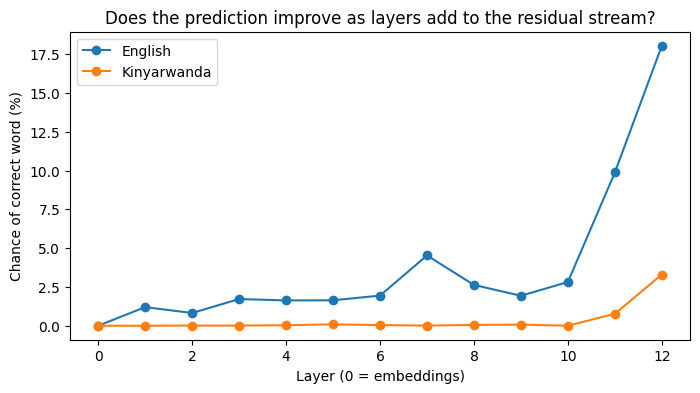

In [3]:
import matplotlib.pyplot as plt

def to_number(col):
    return [float(x.strip('%')) for x in col]

plt.figure(figsize=(8, 4))
plt.plot(to_number(english_table["chance of correct word"]), marker="o", label="English")
plt.plot(to_number(kiny_table["chance of correct word"]), marker="o", label="Kinyarwanda")
plt.xlabel("Layer (0 = embeddings)")
plt.ylabel("Chance of correct word (%)")
plt.title("Does the prediction improve as layers add to the residual stream?")
plt.legend()
plt.show()